# 219. Contains Duplicate II
https://leetcode.com/problems/contains-duplicate-ii/

## Complexity Comparison

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Hash map (value -> index) | $O(n)$ | $O(n)$ | Optimal — store last seen index |
| Sliding window hash set | $O(n)$ | $O(k)$ | Keep set of size k |
| Brute force | $O(n \cdot k)$ | $O(1)$ | Check each window |

## Methodology

Use a hash map to store the most recent index of each value. For each element, check if it exists in the map and the difference between current index and stored index is at most k. If so, return true. Otherwise update the map with the current index.

## Solutions

### C#

In [ ]:
public class Solution {
    public bool ContainsNearbyDuplicate(int[] nums, int k) {
        var map = new Dictionary<int, int>();
        for (int i = 0; i < nums.Length; i++) {
            if (map.TryGetValue(nums[i], out int prev) && i - prev <= k)
                return true;
            map[nums[i]] = i;
        }
        return false;
    }
}

### Python

In [ ]:
class Solution:
    def containsNearbyDuplicate(self, nums: list[int], k: int) -> bool:
        last_seen = {}
        for i, num in enumerate(nums):
            if num in last_seen and i - last_seen[num] <= k:
                return True
            last_seen[num] = i
        return False

### Go

In [ ]:
func containsNearbyDuplicate(nums []int, k int) bool {
    lastSeen := make(map[int]int)
    for i, num := range nums {
        if prev, ok := lastSeen[num]; ok && i-prev <= k {
            return true
        }
        lastSeen[num] = i
    }
    return false
}

### Rust

In [ ]:
use std::collections::HashMap;

impl Solution {
    pub fn contains_nearby_duplicate(nums: Vec<i32>, k: i32) -> bool {
        let k = k as usize;
        let mut last_seen = HashMap::new();
        for (i, &num) in nums.iter().enumerate() {
            if let Some(&prev) = last_seen.get(&num) {
                if i - prev <= k {
                    return true;
                }
            }
            last_seen.insert(num, i);
        }
        false
    }
}

## Example Scenarios

### 1. Common Case — Duplicate Within Distance k
**Input:** `nums = [1, 2, 3, 1], k = 3`

nums[0] = nums[3] = 1. The index distance $|3 - 0| = 3$ which equals $k = 3$, satisfying the constraint. The hash map stores each value's last index and finds the match at $i=3$.

WHY tricky: The boundary condition is $\le k$ (not strictly $< k$), so distance **exactly equal** to $k$ still returns true.

$|i - j| = |3 - 0| = 3 \le k = 3 \Rightarrow$ **Output:** `true`

---

### 2. Slightly Complex — Multiple Duplicates, Closest Pair Wins
**Input:** `nums = [1, 0, 1, 1], k = 1`

The first pair (indices 0,2) has distance 2 > $k=1$, so we update `last_seen[1] = 2`. The second pair (indices 2,3) has distance $1 \le k=1$, so we return true. We must store the **most recent** index of each value.

WHY tricky: If we only stored the first occurrence, we would miss the close pair at indices 2 and 3. Always update: `last_seen[num] = i` to capture closest future matches.

$|2 - 3| = 1 \le k = 1 \Rightarrow$ **Output:** `true`

---

### 3. Edge Case: Time — All Distinct Elements
**Input:** `nums = [1, 2, 3, 4, ..., 100000], k = 99999`

Every element is unique, so no duplicate is ever found. We scan all $n = 10^5$ elements and perform $n$ hash map insertions, returning false only at the end. No early exit is possible.

WHY tricky: Worst case for time — every element triggers an $O(1)$ lookup and insert but there is **no shortcut**. The algorithm must scan the entire array.

$n = 10^5$ lookups + $10^5$ inserts = $O(n)$ total. **Output:** `false`

---

### 4. Edge Case: Space — All Elements Identical
**Input:** `nums = [7, 7, 7, ..., 7]` ($n = 10^5$), `k = 1`

At $i=1$, we find 7 at index 0. Distance $|1-0| = 1 \le k = 1$, return true immediately. The hash map never grows beyond **1 entry** — best case for both space and time.

WHY tricky: Best case for space (map size = 1) AND best case for time (early exit at $i=1$). Contrast with the sliding-window set approach which would also use $O(\min(n,k))$ space.

Map size: 1. Time: $O(1)$ after 2 elements. **Output:** `true`

---

### 5. Almost Impossible — k = 0 (Same-Index Requirement)
**Input:** `nums = [1, 2, 1], k = 0`

With $k=0$, we need $|i-j| \le 0$, meaning $i$ must equal $j$. Since the problem requires distinct indices ($i \ne j$), this is logically impossible. The algorithm naturally returns false because no distinct pair has distance 0.

WHY tricky: $k=0$ creates a **logical impossibility**: you need both $i \ne j$ and $|i-j| \le 0$. Since $|i-j| \ge 1$ for all $i \ne j$, the answer is always false regardless of array contents.

$|i - j| \ge 1$ for all $i \ne j$, but $k = 0$ requires $|i - j| \le 0 \Rightarrow$ **Output:** `false`

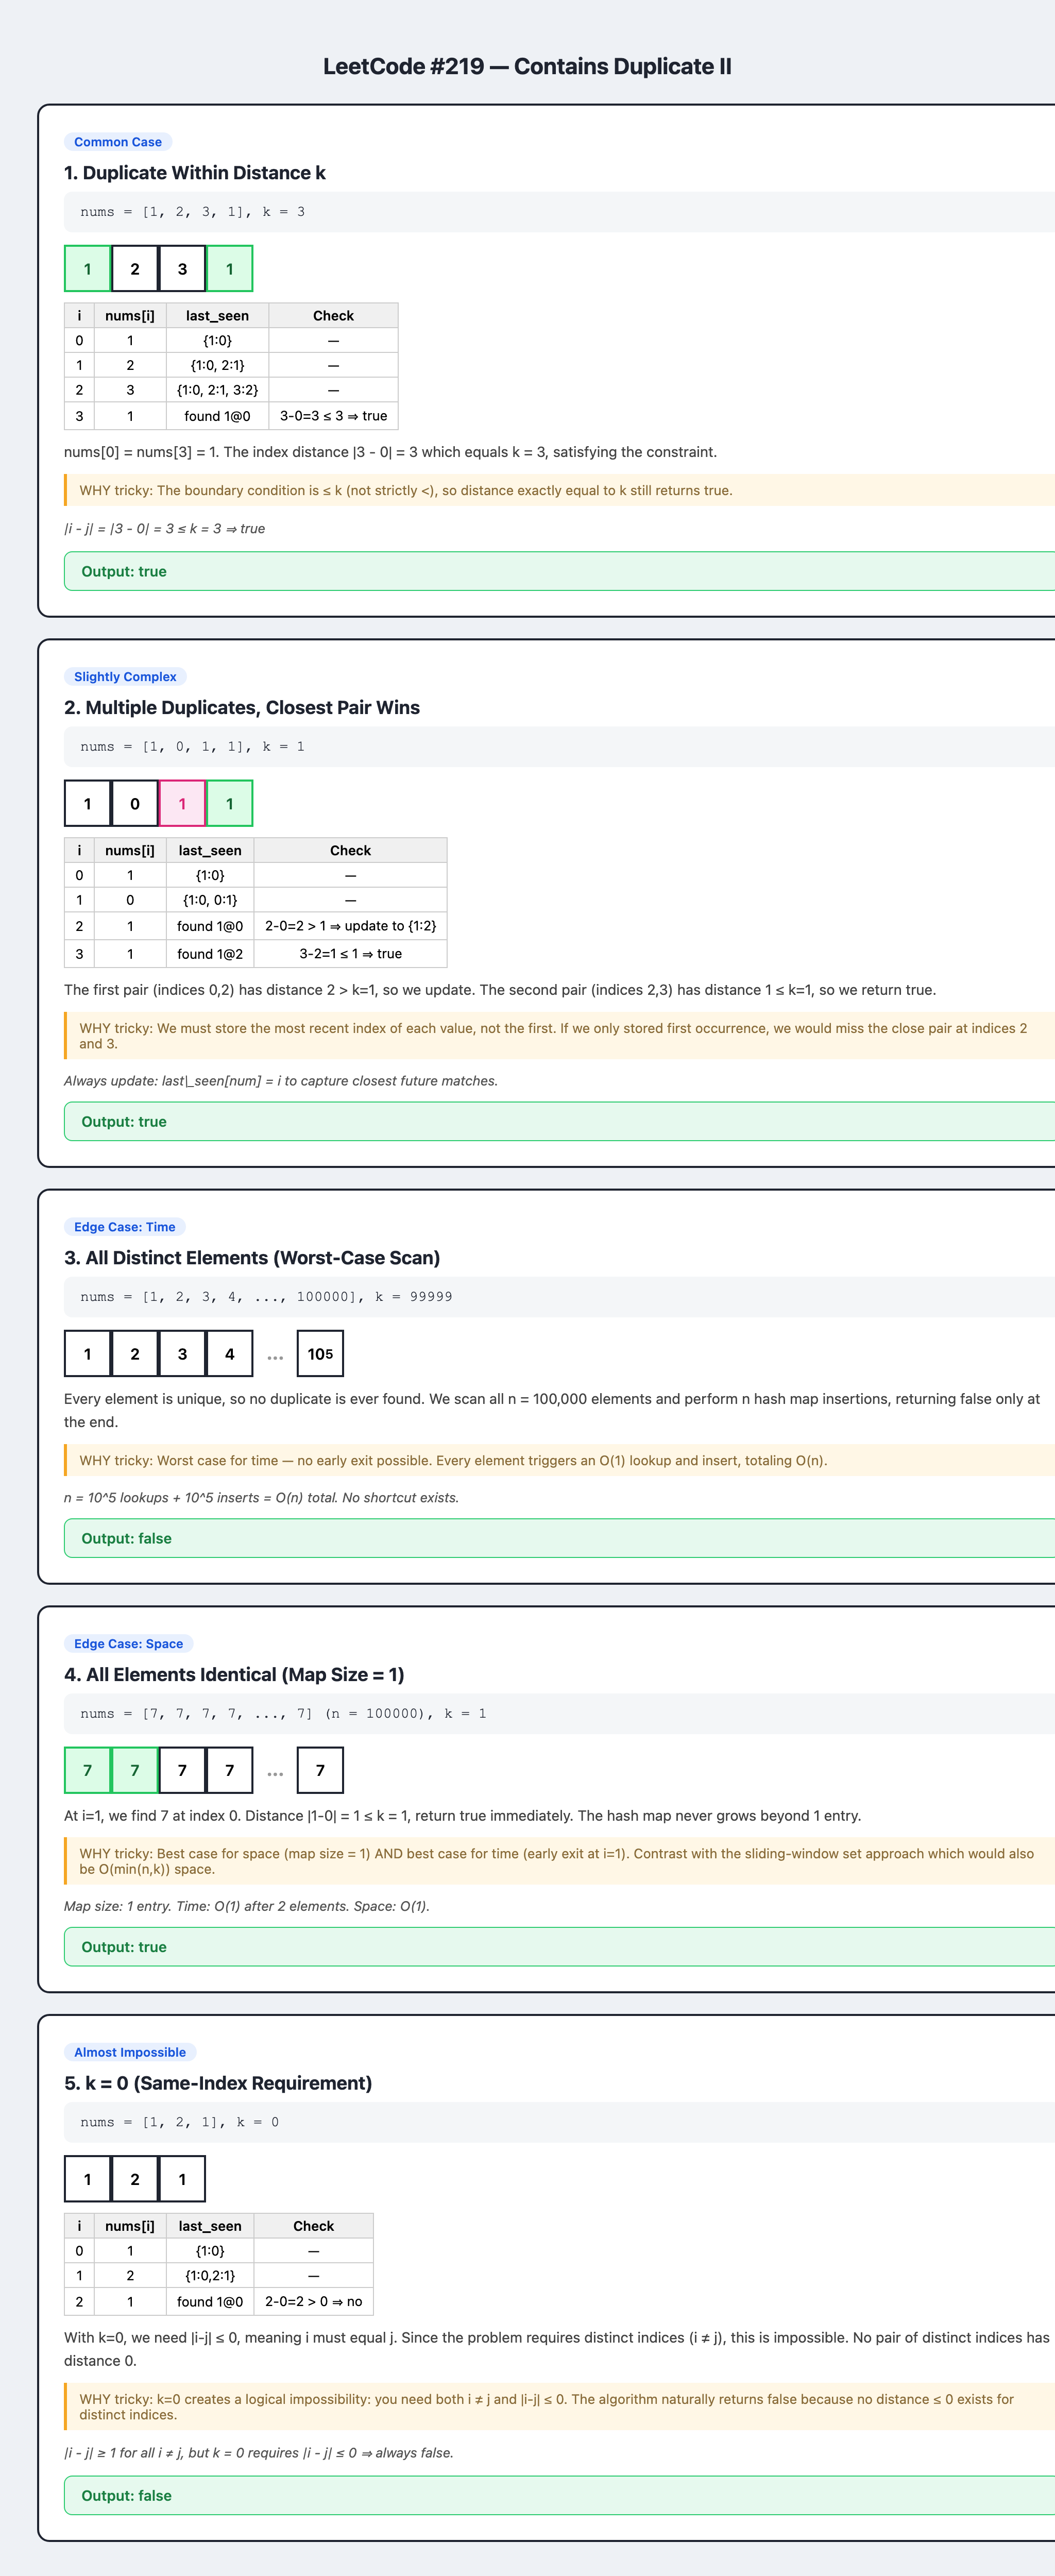